In [1]:
import os

import torch

# torch.cuda.empty_cache()
print(f"torch verison is {torch.__version__}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

SEED = 42
BATCH_SIZE = 32
HEIGHT, WIDTH = 224, 224

TRAIN_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'train')
VALIDATION_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'test')

torch verison is 2.7.1+cu118
cuda


torch shape torch.Size([1, 1858, 2090]) and dtype torch.float32


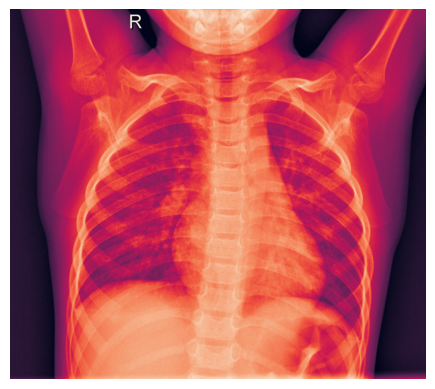

In [4]:
import glob
from PIL import Image

from torchvision import transforms
import matplotlib.pyplot as plt

path = glob.glob(os.path.join(TRAIN_DIR, '**', '*.jpeg'), recursive=True)[0]

# img_pil = Image.open(path).convert('RGB')
img_pil = Image.open(path)
to_tensor = transforms.ToTensor()
img_tensor = to_tensor(img_pil)

print(f"torch shape {img_tensor.shape} and dtype {img_tensor.dtype}")

# visualizing one image
plt.imshow(img_tensor.permute(1, 2, 0))  # C,H,W -> H,W,C
plt.axis('off')
plt.show()


In [21]:
# from torch.utils.data import random_split
# dataset_full = datasets.ImageFolder(root=TRAIN_DIR, transform=None)

# train_size = int(0.8 * len(dataset_full))
# val_size = len(dataset_full) - train_size
# train_dataset, val_dataset = random_split(dataset_full, [train_size, val_size])

# train_dataset.dataset.transform = train_transformation
# val_dataset.dataset.transform = validation_transform


In [5]:
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader

train_transformation = transforms.Compose([transforms.Resize((HEIGHT, WIDTH)),
                                           transforms.Grayscale(num_output_channels=1),
                                           transforms.RandomHorizontalFlip(),
                                           transforms.RandomRotation(5),
                                           transforms.ToTensor(),
                                           ])

validation_transformation = transforms.Compose([transforms.Resize((HEIGHT, WIDTH)),
                                           transforms.Grayscale(num_output_channels=1),
                                           # NO AUGMENTATION HERE!
                                           transforms.ToTensor(),
                                           ])

train_ds = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transformation)
validation_ds = datasets.ImageFolder(root=VALIDATION_DIR, transform=validation_transformation)

train_ds = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
validation_ds = DataLoader(validation_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

images, labels = next(iter(train_ds))
print(f"train_ds size is {len(train_ds.dataset)} -- images shape is {images.shape} -- labels shape is {labels.shape} ")

images, labels = next(iter(validation_ds))
print(
    f"validation_ds size is {len(validation_ds.dataset)} -- images shape is {images.shape} -- labels shape is {labels.shape} ")

train_ds size is 5232 -- images shape is torch.Size([32, 1, 224, 224]) -- labels shape is torch.Size([32]) 
validation_ds size is 624 -- images shape is torch.Size([32, 1, 224, 224]) -- labels shape is torch.Size([32]) 


In [9]:
import torch
import torch.nn as nn


class PneumoniaCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        # Global Average Pooling instead of AdaptivePool
        self.gap = nn.AdaptiveAvgPool2d(1)  # GAP to 1x1
        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.Linear(64, 128),  # 64 features from GAP
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x


model = PneumoniaCNN().to(DEVICE)
# print(model)

from torchsummary import summary
summary(model, input_size=(1, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]             640
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
         MaxPool2d-4         [-1, 64, 112, 112]               0
            Conv2d-5         [-1, 64, 112, 112]          36,928
       BatchNorm2d-6         [-1, 64, 112, 112]             128
              ReLU-7         [-1, 64, 112, 112]               0
         MaxPool2d-8           [-1, 64, 56, 56]               0
            Conv2d-9           [-1, 64, 56, 56]          36,928
      BatchNorm2d-10           [-1, 64, 56, 56]             128
             ReLU-11           [-1, 64, 56, 56]               0
AdaptiveAvgPool2d-12             [-1, 64, 1, 1]               0
          Flatten-13                   [-1, 64]               0
           Linear-14                  [

In [11]:
# criterion = nn.BCEWithLogitsLoss()  # recommended for binary classificatio
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,    weight_decay=0.01 ) #  L2 regularization


from torch.optim.lr_scheduler import ReduceLROnPlateau
# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)


In [13]:
from tqdm import tqdm


# Create lists to store metrics for grapgh plotting
train_losses = []
val_losses = []
train_accs = []
val_accs = []

epochs = 25
best_val_acc = 0.0
patience = 5
patience_counter = 0

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    print(f"Epoch {epoch + 1}/{epochs}")
    print(f"{'-' * 50}")

    progress_bar = tqdm(train_ds, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

    for images, labels in progress_bar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).float().unsqueeze(1)

        optimizer.zero_grad()
        output = model(images)
        output = torch.sigmoid(output)

        loss = criterion(output, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)        #gradinet clipping
        optimizer.step()

        train_loss += loss.item()
        predicted = (output > 0.5).float()
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        # Update progress bar description
        batch_acc = 100.0 * (predicted == labels).sum().item() / labels.size(0)
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'batch_acc': f'{batch_acc:.2f}%'
        })

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in validation_ds:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).float().unsqueeze(1)

            output = model(images)
            output = torch.sigmoid(output)
            loss = criterion(output, labels)

            val_loss += loss.item()
            predicted = (output > 0.5).float()
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate metrics
    train_acc = 100.0 * train_correct / train_total
    val_acc = 100.0 * val_correct / val_total

    # Store in lists for plotting
    train_losses.append(train_loss / len(train_ds))
    val_losses.append(val_loss / len(validation_ds))
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Print epoch summary
    print(f"\n  ▶ Epoch {epoch + 1} Summary:")
    print(f"    Training    - Loss: {train_losses[-1]:.4f}, Acc: {train_acc:.2f}%")
    print(f"    Validation   - Loss: {val_losses[-1]:.4f}, Acc: {val_acc:.2f}%")

    # Save best model with early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_pneumonia_model.pth')
        print(f"  → New best model saved! ({val_acc:.2f}%)")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(torch.load('best_pneumonia_model.pth'))
            break

# Print summary
print("\n" + "-" * 50)
print("TRAINING SUMMARY")
print("-" * 50)
print(f"Best Validation Accuracy: {best_val_acc:.2f}% at epoch {val_accs.index(best_val_acc) + 1}")
print(f"Final Training Accuracy: {train_accs[-1]:.2f}%")
print(f"Final Validation Accuracy: {val_accs[-1]:.2f}%")

Epoch 1/25
--------------------------------------------------


Epoch 1/25: 100%|██████████| 164/164 [00:26<00:00,  6.17it/s, loss=0.4204, batch_acc=81.25%] 



  ▶ Epoch 1 Summary:
    Train - Loss: 0.3384, Acc: 85.70%
    Val   - Loss: 0.4767, Acc: 81.41%
  → New best model saved! (81.41%)
Epoch 2/25
--------------------------------------------------


Epoch 2/25: 100%|██████████| 164/164 [00:26<00:00,  6.14it/s, loss=0.3607, batch_acc=81.25%]



  ▶ Epoch 2 Summary:
    Train - Loss: 0.3261, Acc: 86.53%
    Val   - Loss: 0.7913, Acc: 62.66%
Epoch 3/25
--------------------------------------------------


...


  ▶ Epoch 4 Summary:
    Train - Loss: 0.2985, Acc: 89.12%
    Val   - Loss: 0.5063, Acc: 72.12%
Epoch 5/25
--------------------------------------------------


Epoch 5/25: 100%|██████████| 164/164 [00:25<00:00,  6.31it/s, loss=0.3040, batch_acc=81.25%]



  ▶ Epoch 5 Summary:
    Train - Loss: 0.2988, Acc: 88.44%
    Val   - Loss: 0.5543, Acc: 72.44%
Epoch 6/25
--------------------------------------------------


Epoch 6/25: 100%|██████████| 164/164 [00:26<00:00,  6.28it/s, loss=0.3419, batch_acc=81.25%]



  ▶ Epoch 6 Summary:
    Train - Loss: 0.2850, Acc: 89.74%
    Val   - Loss: 0.4558, Acc: 78.21%
Early stopping at epoch 6

--------------------------------------------------
TRAINING SUMMARY
--------------------------------------------------
Best Validation Accuracy: 81.41% at epoch 1
Final Training Accuracy: 89.74%
Final Validation Accuracy: 78.21%


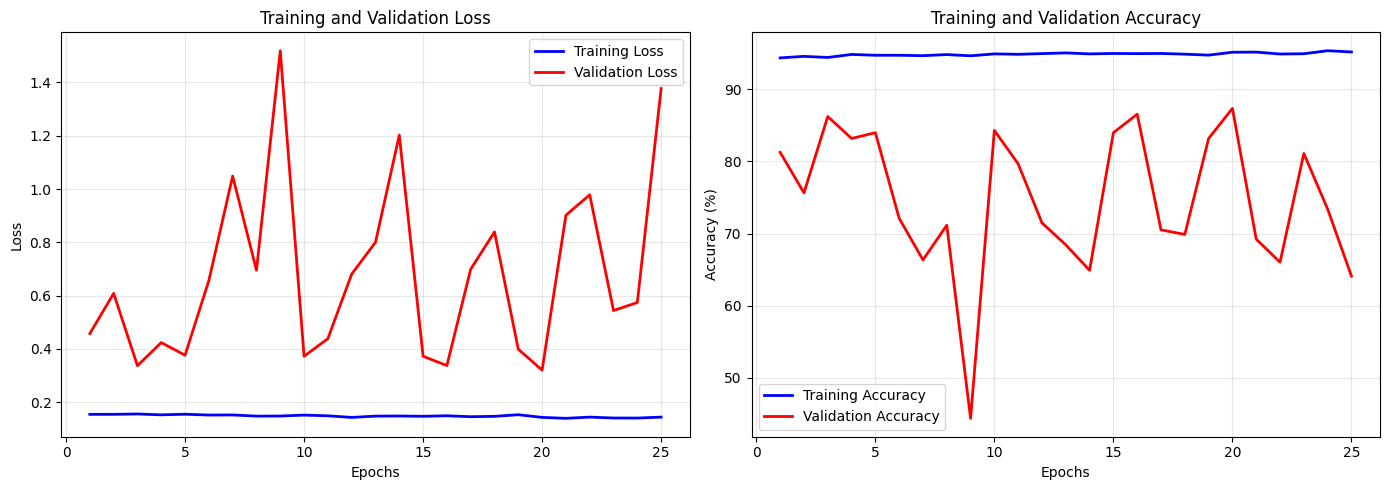

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accs, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(range(1, epochs + 1), val_accs, 'r-', label='Validation Accuracy', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()